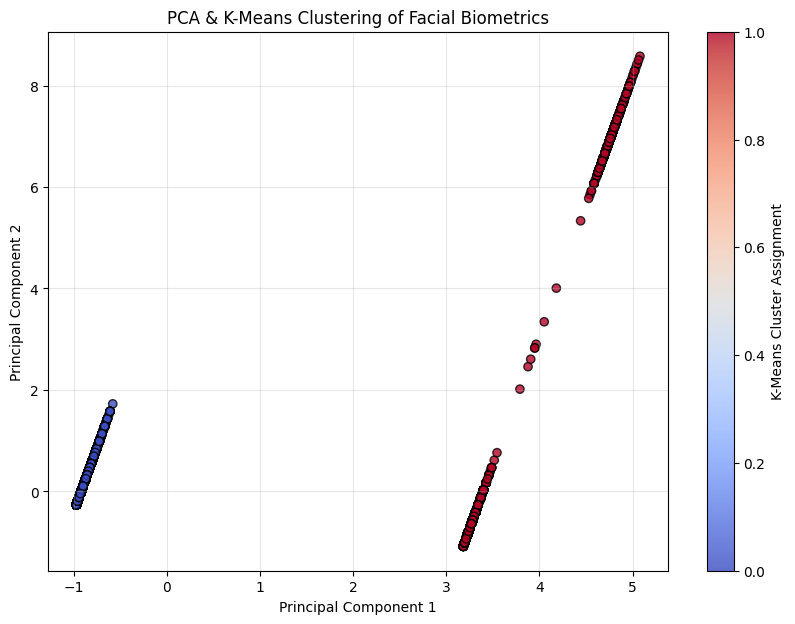

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the real data you just generated!
df = pd.read_csv('drowsiness_data.csv')

# 2. Isolate the features (ignoring the 'state' column for a moment)
features = df[['ear', 'blink_duration', 'mar', 'head_deviation']]

# 3. Scale the data 
# This ensures that a small variance in EAR isn't overshadowed by a larger variance in MAR
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. Dimensionality Reduction (PCA)
# Shrinking 4 dimensions of biometric data down to 2 dimensions
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_features)

# 5. Clustering (K-Means)
# We ask the algorithm to find 2 distinct groups in the raw numbers
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(reduced_data)

# 6. Visualize the hidden structure
plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='coolwarm', alpha=0.8, edgecolor='k')
plt.title("PCA & K-Means Clustering of Facial Biometrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="K-Means Cluster Assignment")
plt.grid(True, alpha=0.3)
plt.show()